In [224]:
import pandas as pd
import numpy as np
import re

import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

# Imputaciones

El Modelo 1 tiene como objetivo estimar la probabilidad de aprobación del crédito (estado de desembolso) a partir del perfil del cliente. Para ello, se seleccionaron las variables EDAD_AL_PRESTAMO, MONTO, PLAZO, TIPO_CREDITO y PAGADURIA, ya que representan factores clave en la decisión crediticia: la edad y la pagaduría reflejan el perfil y estabilidad del cliente, mientras que el monto, el plazo y el tipo de crédito describen las condiciones de la solicitud. Estas variables capturan tanto características demográficas como financieras, permitiendo modelar de forma adecuada la probabilidad de aprobación.

In [225]:
df = pd.read_csv('../data/dataset_limpio.csv')

In [226]:
df.head()

,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO,DIAS_HASTA_DESEMBOLSO,MONTO_M,ANIO,MES
0,31880483.0,2019-01-08,REFINANCIACIÓN,BUSINESS,2700000.0,48.0,COLPENSIONES,1961.0,DESEMBOLSADO,2022-02-21,58.0,NaN,2.70,2019.0,1.0
1,25209823.0,2019-05-29,LIBRE INVERSIÓN,COOPIDESARROLLO,6000000.0,36.0,COLPENSIONES,1939.0,DESEMBOLSADO,2019-06-11,80.0,13.0,6.00,2019.0,5.0
2,105913.0,2019-05-30,LIBRE INVERSIÓN,COOPIDESARROLLO,5000000.0,48.0,CAGEN,1944.0,DESEMBOLSADO,2019-06-25,75.0,26.0,5.00,2019.0,5.0
3,66839228.0,2019-05-30,COMPRA DE CARTERA,CREDIVALORES,24000000.0,120.0,CASUR,1972.0,DESEMBOLSADO,2019-06-28,47.0,29.0,24.00,2019.0,5.0
4,38557017.0,2019-06-04,COMPRA DE CARTERA,EXCELCREDIT,7560000.0,120.0,CAGEN,1980.0,DESEMBOLSADO,2019-07-05,39.0,NaN,7.56,2019.0,6.0


In [227]:
df.isnull().sum()

ID_CLIENTE                 1
FECHA                      3
TIPO DE CREDITO            9
COOPERATIVA                9
MONTO                    213
PLAZO                     13
PAGADURIA                  2
ANIO_NACIMIENTO          103
ESTADO                     1
FECHA DE DESEMBOLSO      468
EDAD_AL_PRESTAMO         167
DIAS_HASTA_DESEMBOLSO    624
MONTO_M                  213
ANIO                       3
MES                        3
dtype: int64

En la etapa de preparación de datos se identificaron valores faltantes en variables clave del modelo, principalmente en MONTO (12.9%), EDAD_AL_PRESTAMO (10.1%) y en menor medida en PLAZO (0.8%). Dado que estas variables son fundamentales para estimar la probabilidad de aprobación, no se optó por eliminar registros. El análisis de sus distribuciones evidenció asimetrías y comportamientos no normales, por lo que se descartaron métodos de imputación basados en media o mediana, debido a que pueden distorsionar la densidad original de los datos.

En su lugar, se implementó una imputación basada en muestreo aleatorio por grupos, preservando la distribución original. Para MONTO y PLAZO, se utilizó TIPO DE CREDITO como variable de agrupación, mientras que para EDAD_AL_PRESTAMO se empleó PAGADURIA. En caso de ausencia de datos dentro de un grupo, se recurrió a la distribución global como respaldo. Las variables categóricas se completaron con la categoría "DESCONOCIDO". La validación mediante gráficos de densidad antes y después de la imputación mostró una alta superposición, confirmando que el método conserva la estructura de los datos sin introducir sesgos significativos.

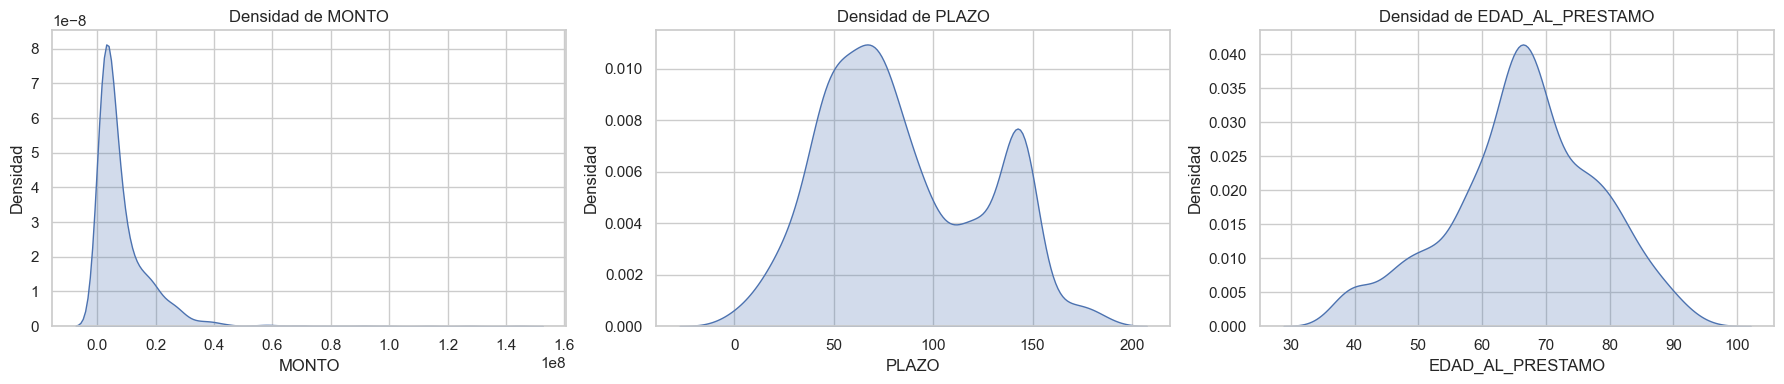

In [228]:
import math
variables_numericas = [
    "MONTO",
    "PLAZO",
    "EDAD_AL_PRESTAMO",
]

cols_existentes = [col for col in variables_numericas if col in df.columns]
n_cols = 3
n_rows = math.ceil(len(cols_existentes) / n_cols)

sns.set(style="whitegrid")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_existentes):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i])
    axes[i].set_title(f'Densidad de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')

for j in range(len(cols_existentes), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [229]:
np.random.seed(42)

df_original = df.copy()
df_imp = df.copy()

# CATEGORICAS
df_imp['TIPO DE CREDITO'] = df_imp['TIPO DE CREDITO'].fillna('DESCONOCIDO')
df_imp['PAGADURIA'] = df_imp['PAGADURIA'].fillna('DESCONOCIDO')

def imputar_sampling(grupo, valores_globales):
    valores = grupo.dropna()
    
    if len(valores) == 0:
        valores = valores_globales
        
    return grupo.apply(lambda x: np.random.choice(valores) if pd.isna(x) else x)

# VALORES GLOBALES
global_monto = df_imp['MONTO'].dropna()
global_plazo = df_imp['PLAZO'].dropna()
global_edad = df_imp['EDAD_AL_PRESTAMO'].dropna()

# MONTO
df_imp['MONTO'] = df_imp.groupby('TIPO DE CREDITO')['MONTO'].transform(
    lambda g: imputar_sampling(g, global_monto)
)

# PLAZO
df_imp['PLAZO'] = df_imp.groupby('TIPO DE CREDITO')['PLAZO'].transform(
    lambda g: imputar_sampling(g, global_plazo)
)

# EDAD_AL_PRESTAMo
df_imp['EDAD_AL_PRESTAMO'] = df_imp.groupby('PAGADURIA')['EDAD_AL_PRESTAMO'].transform(
    lambda g: imputar_sampling(g, global_edad)
)

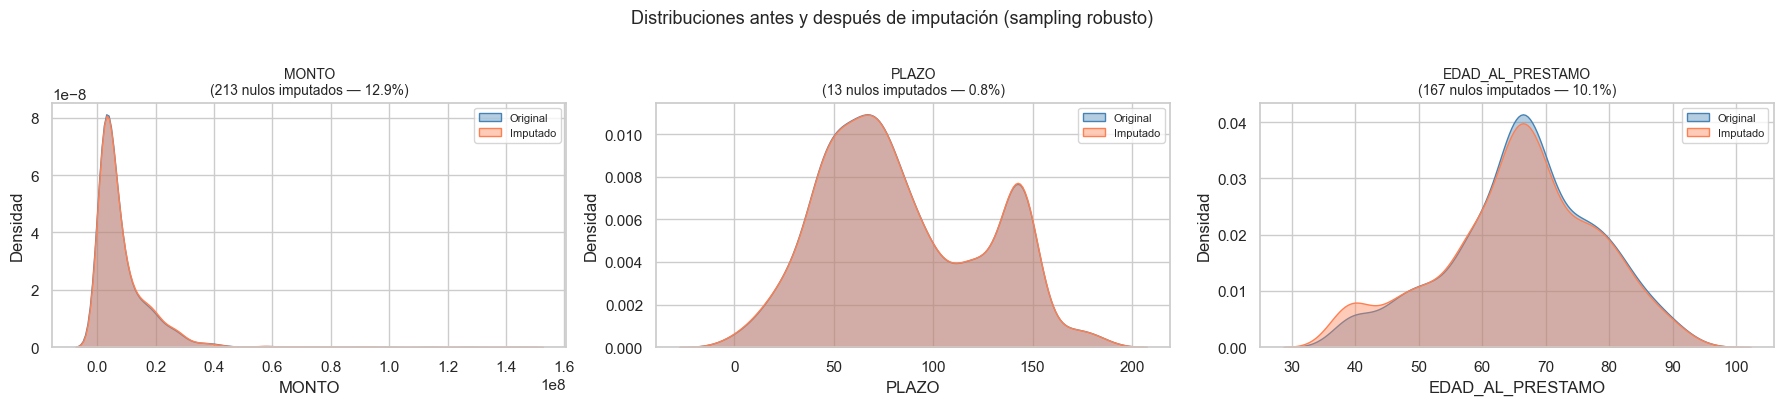

In [230]:

variables_numericas = [
    "MONTO",
    "PLAZO",
    "EDAD_AL_PRESTAMO",
]

cols_existentes = [col for col in variables_numericas if col in df_original.columns]

n_cols = 3
n_rows = math.ceil(len(cols_existentes) / n_cols)

sns.set(style="whitegrid")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_existentes):
    ax = axes[i]

    sns.kdeplot(
        data=df_original[df_original[col].notna()],
        x=col,
        fill=True,
        alpha=0.4,
        color="steelblue",
        label="Original",
        ax=ax
    )

    sns.kdeplot(
        data=df_imp[df_imp[col].notna()],
        x=col,
        fill=True,
        alpha=0.4,
        color="coral",
        label="Imputado",
        ax=ax
    )

    #cuántos nulos había originalmente
    n_nulos = df_original[col].isna().sum()
    pct_nulos = n_nulos / len(df_original) * 100
    ax.set_title(f'{col}\n({n_nulos} nulos imputados — {pct_nulos:.1f}%)', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

for j in range(len(cols_existentes), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones antes y después de imputación (sampling robusto)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Ingenieria de características

**num_creditos_totales:**
Corresponde al número total de créditos registrados para cada cliente en el histórico de la base de datos. Esta variable se creó con el fin de medir la experiencia crediticia del cliente, ya que un mayor número de créditos permite inferir un comportamiento financiero más conocido y evaluable por la entidad.

In [231]:
rfm = df_imp.groupby('ID_CLIENTE').agg(
    num_creditos_totales=('ID_CLIENTE', 'count')
).reset_index()

**dias_desde_ultimo_credito:**
Representa la cantidad de días transcurridos desde la última solicitud de crédito realizada por el cliente, calculada a partir de la variable FECHA. Esta variable se diseñó para capturar la recencia de la actividad crediticia, lo cual es relevante para estimar la capacidad actual de endeudamiento.

In [232]:
df_imp['FECHA'] = pd.to_datetime(df_imp['FECHA'])

fecha_referencia = pd.Timestamp.today().normalize()  

rfm2 = df_imp.groupby('ID_CLIENTE').agg(
    fecha_ultimo_credito=('FECHA', 'max')
).reset_index()

rfm2['dias_desde_ultimo_credito'] = (fecha_referencia - rfm2['fecha_ultimo_credito']).dt.days

**monto_promedio:**
Es el valor promedio de los montos de crédito solicitados por el cliente en su historial. Se creó para reflejar la capacidad financiera histórica del cliente, permitiendo evaluar si el monto solicitado en la operación actual es consistente con su comportamiento previo.

In [233]:
rfm4 = df_imp.groupby('ID_CLIENTE').agg(
    monto_promedio=('MONTO', 'mean')
).reset_index()

**plazo_promedio**
Corresponde al promedio de los plazos de los créditos del cliente, medidos en meses. Esta variable permite caracterizar el perfil de endeudamiento del cliente, ya que los plazos pueden estar asociados a diferentes niveles de riesgo y capacidad de pago.

In [234]:
rfm5 = df_imp.groupby('ID_CLIENTE').agg(
    plazo_promedio=('PLAZO', 'mean')
).reset_index()

**ha_refinanciado:**
Es una variable binaria que indica si el cliente ha registrado al menos un crédito de tipo refinanciación en su historial (1 si ha refinanciado, 0 en caso contrario). Se creó para incorporar información sobre el comportamiento financiero pasado del cliente, dado que la refinanciación puede estar asociada a patrones relevantes en la gestión de sus obligaciones crediticias.

In [235]:
df_imp['flag_refinanciado'] = (df_imp['TIPO DE CREDITO'] == 'REFINANCIACIÓN').astype(int)

rfm6 = df_imp.groupby('ID_CLIENTE').agg(
    ha_refinanciado=('flag_refinanciado', 'max')
).reset_index()

In [236]:
df_imp.info()

<class 'pandas.DataFrame'>
RangeIndex: 1657 entries, 0 to 1656
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID_CLIENTE             1656 non-null   float64       
 1   FECHA                  1654 non-null   datetime64[us]
 2   TIPO DE CREDITO        1657 non-null   str           
 3   COOPERATIVA            1648 non-null   str           
 4   MONTO                  1657 non-null   float64       
 5   PLAZO                  1657 non-null   float64       
 6   PAGADURIA              1657 non-null   str           
 7   ANIO_NACIMIENTO        1554 non-null   float64       
 8   ESTADO                 1656 non-null   str           
 9   FECHA DE DESEMBOLSO    1189 non-null   str           
 10  EDAD_AL_PRESTAMO       1657 non-null   float64       
 11  DIAS_HASTA_DESEMBOLSO  1033 non-null   float64       
 12  MONTO_M                1444 non-null   float64       
 13  ANIO          

In [237]:
# unir todo paso a paso
df_imp = df_imp.merge(rfm, on='ID_CLIENTE', how='left')
df_imp = df_imp.merge(rfm2, on='ID_CLIENTE', how='left')
df_imp = df_imp.merge(rfm4, on='ID_CLIENTE', how='left')
df_imp = df_imp.merge(rfm5, on='ID_CLIENTE', how='left')

In [238]:
df_imp.info()

<class 'pandas.DataFrame'>
RangeIndex: 1657 entries, 0 to 1656
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ID_CLIENTE                 1656 non-null   float64       
 1   FECHA                      1654 non-null   datetime64[us]
 2   TIPO DE CREDITO            1657 non-null   str           
 3   COOPERATIVA                1648 non-null   str           
 4   MONTO                      1657 non-null   float64       
 5   PLAZO                      1657 non-null   float64       
 6   PAGADURIA                  1657 non-null   str           
 7   ANIO_NACIMIENTO            1554 non-null   float64       
 8   ESTADO                     1656 non-null   str           
 9   FECHA DE DESEMBOLSO        1189 non-null   str           
 10  EDAD_AL_PRESTAMO           1657 non-null   float64       
 11  DIAS_HASTA_DESEMBOLSO      1033 non-null   float64       
 12  MONTO_M          

# Codificación de variables categóricas

Las variables categóricas TIPO DE CREDITO y PAGADURIA fueron transformadas a formato numérico para su uso en los modelos de aprendizaje automático. Inicialmente, los valores faltantes en ambas variables se reemplazaron por la categoría "DESCONOCIDO", con el fin de evitar la pérdida de registros y mantener la integridad del conjunto de datos. Posteriormente, se aplicó One-Hot Encoding a la variable TIPO DE CREDITO, generando variables binarias para cada categoría y utilizando drop_first=True para prevenir problemas de multicolinealidad, dejando una categoría base implícita en el modelo.

En el caso de PAGADURIA, debido a la alta cantidad de categorías con baja frecuencia, se realizó un proceso de agrupación en el que se conservaron únicamente las más representativas y el resto se consolidó en la categoría "OTROS". Esta estrategia permitió reducir la dimensionalidad y el ruido en los datos. Posteriormente, se aplicó también One-Hot Encoding con drop_first=True, logrando una representación numérica adecuada de las categorías. Este proceso permitió incorporar de manera eficiente la información categórica al modelo, facilitando su uso en la estimación de la probabilidad de aprobación del crédito.

In [239]:
df_imp['TIPO DE CREDITO'] = df_imp['TIPO DE CREDITO'].fillna('DESCONOCIDO')
df_imp['PAGADURIA'] = df_imp['PAGADURIA'].fillna('DESCONOCIDO')

In [240]:
print("TIPO DE CREDITO:")
print(df_imp['TIPO DE CREDITO'].unique())

print("\nPAGADURIA:")
print(df_imp['PAGADURIA'].unique())

TIPO DE CREDITO:
<StringArray>
[   'REFINANCIACIÓN',   'LIBRE INVERSIÓN', 'COMPRA DE CARTERA',
             'OTROS',       'DESCONOCIDO']
Length: 5, dtype: str

PAGADURIA:
<StringArray>
[       'COLPENSIONES',               'CAGEN',               'CASUR',
            'PORVENIR', 'SOLDADO PROFESIONAL',    'POLICIA NACIONAL',
       'FIDUPREVISORA',               'FOPEP',           'COLFONDOS',
               'TEGEN',          'PROTECCION',              'CREMIL',
          'MINDEFENSA',              'MAPFRE',       'FERROCARRILES',
        'SEGUROS ALFA',     'SEGUROS BOLIVAR',  'MUNICIPIO/ALCALDIA',
           'ECOPETROL',      'SEC. EDUCACION',                'SURA',
         'GOBERNACION',            'EMPLEADO',        'BBVA SEGUROS',
            'EJERCITO',              'ACTIVO',      'GLOBAL SEGUROS',
  'SEGUROS LA EQUIDAD',            'POSITIVA',                 'SEM',
     'ALLIANZ SEGUROS',       'AXA COLPATRIA',             'INCAUCA',
            'FISCALIA',             'ASULADO

TIPO DE CREDITO - One Hot Encoding

In [241]:
df_imp = pd.get_dummies(df_imp, columns=['TIPO DE CREDITO'], drop_first=True)

PAGADURÍA - One Hot Encoding

In [242]:
pagadurias_principales = [
    'COLPENSIONES', 'CASUR', 'SEGUROS ALFA', 'FOPEP', 'PORVENIR',
    'COLFONDOS', 'FIDUPREVISORA', 'SEGUROS BOLIVAR',
    'PROTECCION', 'FERROCARRILES'
]

df_imp['PAGADURIA'] = df_imp['PAGADURIA'].apply(
    lambda x: x if x in pagadurias_principales else 'OTROS'
)

In [243]:
print(df_imp['PAGADURIA'].value_counts())

PAGADURIA
COLPENSIONES       973
OTROS              222
CASUR               81
SEGUROS ALFA        72
FOPEP               62
PORVENIR            61
COLFONDOS           52
FIDUPREVISORA       40
SEGUROS BOLIVAR     37
PROTECCION          29
FERROCARRILES       28
Name: count, dtype: int64


In [244]:
df_imp = pd.get_dummies(df_imp, columns=['PAGADURIA'], drop_first=True)

In [245]:
dummy_cols = [col for col in df_imp.columns if 'PAGADURIA_' in col]
print(dummy_cols)

['PAGADURIA_COLFONDOS', 'PAGADURIA_COLPENSIONES', 'PAGADURIA_FERROCARRILES', 'PAGADURIA_FIDUPREVISORA', 'PAGADURIA_FOPEP', 'PAGADURIA_OTROS', 'PAGADURIA_PORVENIR', 'PAGADURIA_PROTECCION', 'PAGADURIA_SEGUROS ALFA', 'PAGADURIA_SEGUROS BOLIVAR']


# EDA necesario para saber que variables aportan al modelo

Como parte del análisis exploratorio de datos (EDA), se realizó una depuración del conjunto de datos con el fin de garantizar su calidad para el modelado. Se excluyeron aquellos en estado "EN_PROCESO", dado que no representan un resultado final del crédito. A partir de esto, se definió una variable objetivo binaria (target), donde 1 corresponde a créditos desembolsados y 0 a no desembolsados, permitiendo estructurar el problema como una tarea de clasificación.

Posteriormente, se llevó a cabo un proceso de selección de variables, eliminando aquellas que no aportaban valor predictivo o que podían generar fuga de información, como identificadores, variables temporales directas y variables derivadas redundantes. Esto permitió construir una matriz de características coherente con el objetivo del modelo. El análisis de correlación evidenció que variables como dias_desde_ultimo_credito y PLAZO presentan relación negativa con la probabilidad de aprobación, mientras que num_creditos_totales muestra una relación positiva, destacándose como una variable relevante para el modelo.

Finalmente, el análisis gráfico mediante boxplots, histogramas y pairplots permitió validar la capacidad discriminativa de las variables. Se observó que, aunque algunas variables presentan cierta separación entre clases, en general existe un alto solapamiento, lo que indica que el problema no es linealmente separable. Esto evidencia la presencia de relaciones complejas y no lineales en los datos, lo cual justifica el uso de modelos como Random Forest, capaces de capturar este tipo de patrones y ofrecer un mejor desempeño en la predicción de la probabilidad de aprobación del crédito.

In [246]:
df_imp = df_imp[df_imp['num_creditos_totales'].notna()]

In [247]:
print(df_imp['ESTADO'].value_counts(dropna=False))

ESTADO
DESEMBOLSADO       1281
NO_DESEMBOLSADO     330
EN_PROCESO           45
Name: count, dtype: int64


In [248]:
# eliminar registros en proceso
df_imp = df_imp[df_imp['ESTADO'] != 'EN_PROCESO']

# crear target binario
df_imp['target'] = df_imp['ESTADO'].map({
    'DESEMBOLSADO': 1,
    'NO_DESEMBOLSADO': 0
})
print(df_imp['target'].value_counts())

target
1    1281
0     330
Name: count, dtype: int64


In [249]:
columnas_excluir = [
    'ID_CLIENTE',
    'ESTADO',
    'FECHA',
    'FECHA DE DESEMBOLSO',
    'DIAS_HASTA_DESEMBOLSO',
    'MONTO_M',
    'ANIO',
    'MES',
    'ANIO_NACIMIENTO',
    'COOPERATIVA',
    'fecha_ultimo_credito'
    
    
    
]

columnas_excluir = [c for c in columnas_excluir if c in df_imp.columns]
print("Columnas a excluir:", columnas_excluir)

Columnas a excluir: ['ID_CLIENTE', 'ESTADO', 'FECHA', 'FECHA DE DESEMBOLSO', 'DIAS_HASTA_DESEMBOLSO', 'MONTO_M', 'ANIO', 'MES', 'ANIO_NACIMIENTO', 'COOPERATIVA', 'fecha_ultimo_credito']


In [250]:
#Construir X e y
X = df_imp.drop(columns=columnas_excluir + ['target'], errors='ignore')
y = df_imp['target']
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (1611, 22)
Shape y: (1611,)


In [251]:
# mostrar variables numéricas|
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("Variables numéricas:")
print(num_cols)

Variables numéricas:
['MONTO', 'PLAZO', 'EDAD_AL_PRESTAMO', 'flag_refinanciado', 'num_creditos_totales', 'dias_desde_ultimo_credito', 'monto_promedio', 'plazo_promedio']


In [252]:
# Correlación entre variables numéricas con el target

corr_target = pd.concat([X[num_cols], y], axis=1).corr(numeric_only=True)['target'] \
    .drop('target') \
    .sort_values(key=abs, ascending=False)

print(corr_target)

dias_desde_ultimo_credito   -0.230365
PLAZO                       -0.189469
num_creditos_totales         0.169757
plazo_promedio              -0.153780
MONTO                       -0.102051
monto_promedio              -0.066193
flag_refinanciado            0.034267
EDAD_AL_PRESTAMO             0.013373
Name: target, dtype: float64


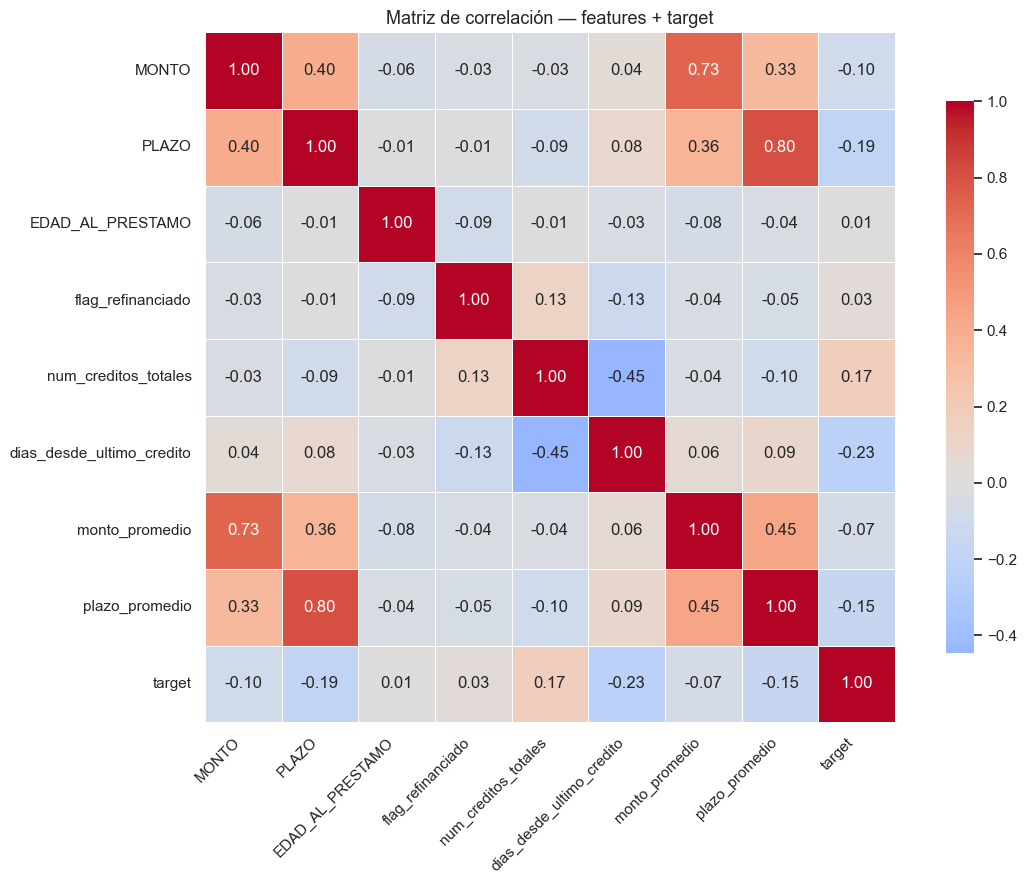

In [253]:
# Matriz de correlación
corr_matrix = pd.concat([X[num_cols], y], axis=1).corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de correlación — features + target', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [254]:
corr = pd.concat([X, y], axis=1).corr(numeric_only=True)

corr_target = corr['target'].drop('target').sort_values(key=abs, ascending=False)

print(corr_target)

dias_desde_ultimo_credito         -0.230365
PLAZO                             -0.189469
num_creditos_totales               0.169757
TIPO DE CREDITO_LIBRE INVERSIÓN    0.156482
plazo_promedio                    -0.153780
PAGADURIA_OTROS                   -0.112962
MONTO                             -0.102051
monto_promedio                    -0.066193
PAGADURIA_COLPENSIONES             0.065572
PAGADURIA_FIDUPREVISORA           -0.057392
PAGADURIA_PORVENIR                 0.045939
TIPO DE CREDITO_REFINANCIACIÓN     0.034267
flag_refinanciado                  0.034267
PAGADURIA_PROTECCION               0.034015
PAGADURIA_COLFONDOS                0.030280
TIPO DE CREDITO_OTROS              0.028320
PAGADURIA_FERROCARRILES           -0.026650
PAGADURIA_SEGUROS BOLIVAR          0.026481
PAGADURIA_FOPEP                   -0.018388
EDAD_AL_PRESTAMO                   0.013373
PAGADURIA_SEGUROS ALFA            -0.012532
TIPO DE CREDITO_DESCONOCIDO        0.005783
Name: target, dtype: float64


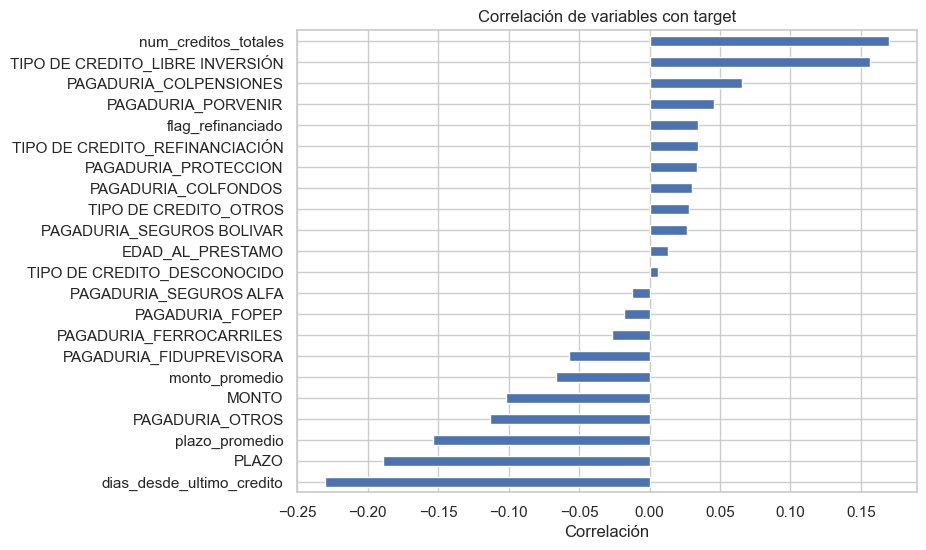

In [255]:
plt.figure(figsize=(8,6))
corr_target.sort_values().plot(kind='barh')
plt.title("Correlación de variables con target")
plt.xlabel("Correlación")
plt.show()

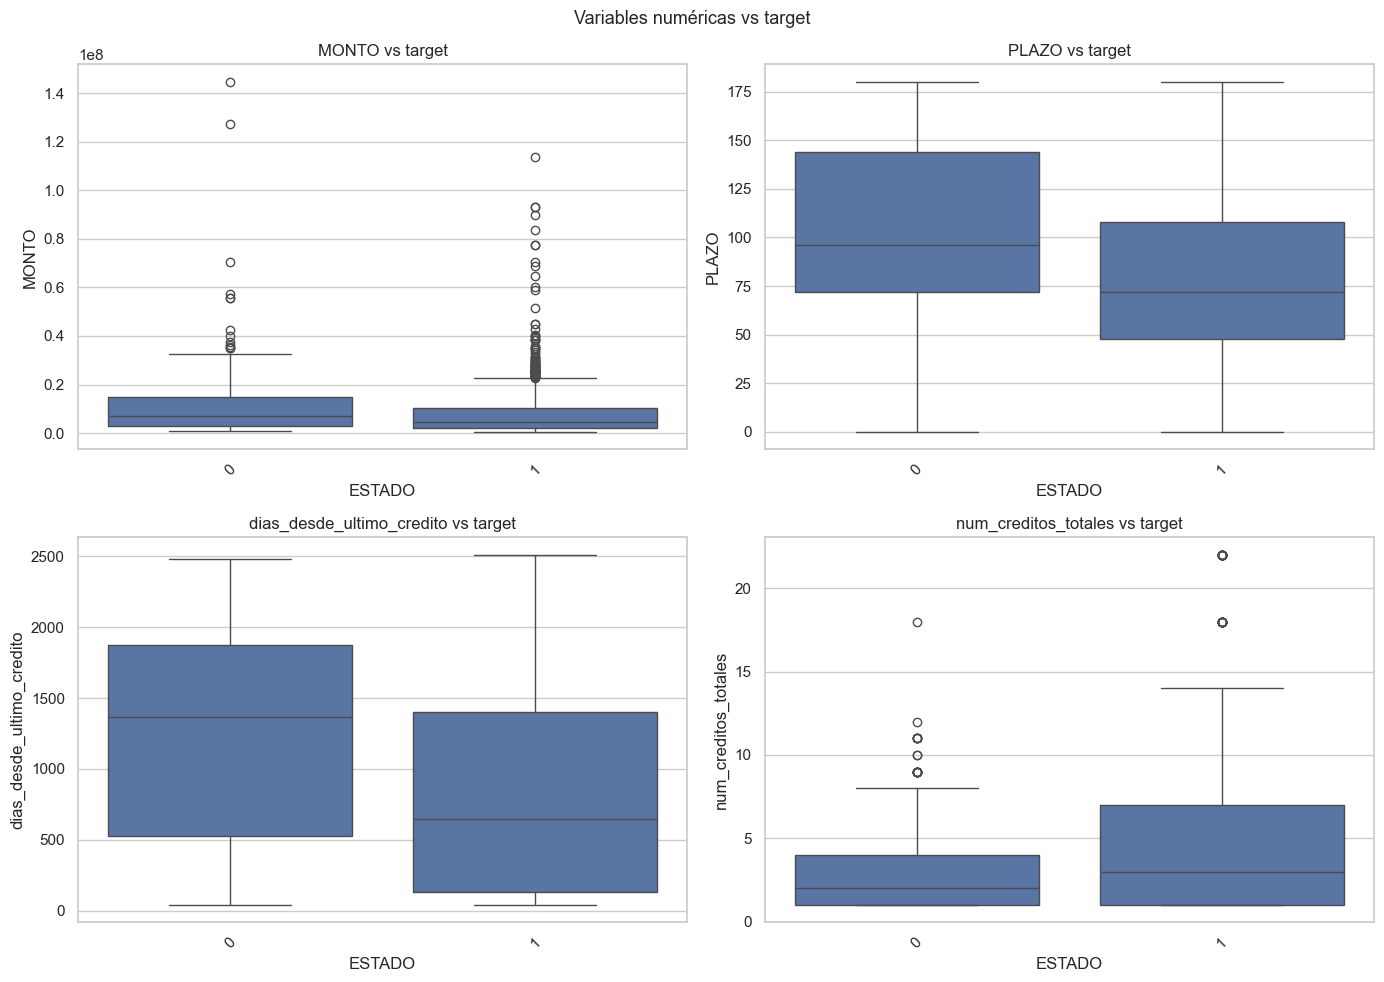

In [256]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(['MONTO', 'PLAZO', 'dias_desde_ultimo_credito', 'num_creditos_totales']):
    sns.boxplot(x=y, y=X[col], ax=axes[i])
    axes[i].set_title(f'{col} vs target')
    axes[i].set_xlabel('ESTADO')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Variables numéricas vs target', fontsize=13)
plt.tight_layout()
plt.show()

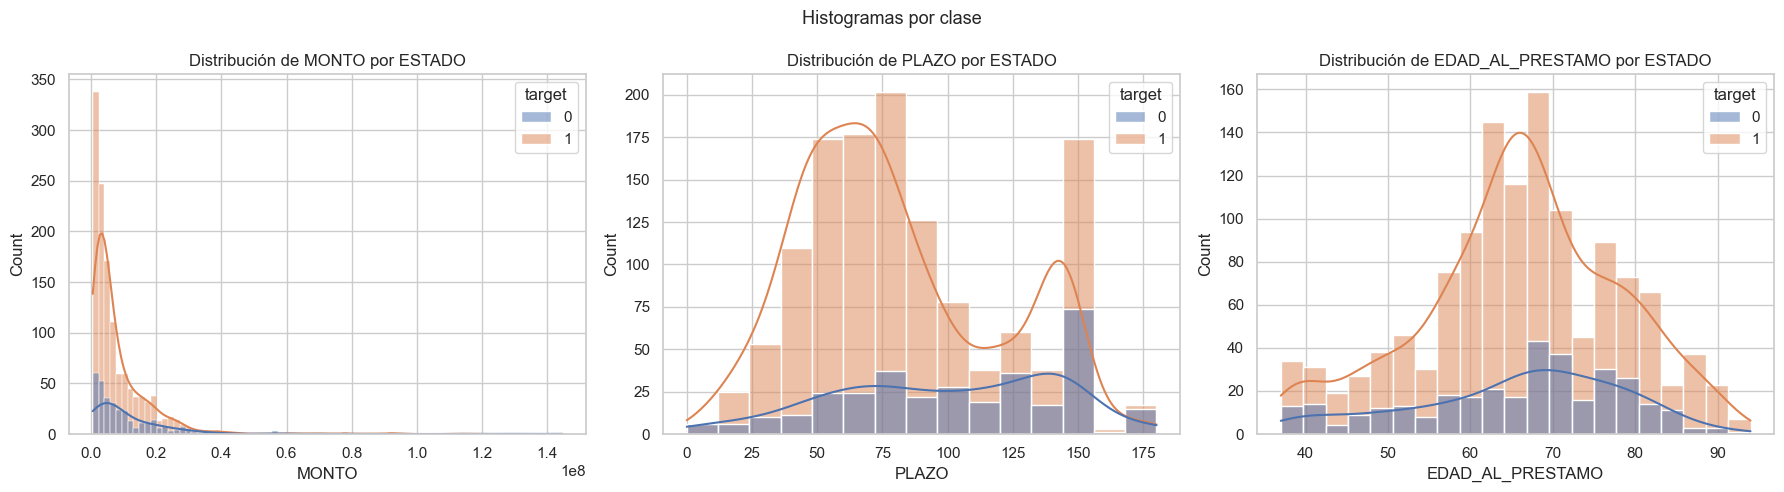

In [257]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['MONTO', 'PLAZO', 'EDAD_AL_PRESTAMO']):
    sns.histplot(
        data=pd.concat([X, y], axis=1),
        x=col,
        hue='target',
        kde=True,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribución de {col} por ESTADO')

plt.suptitle('Histogramas por clase', fontsize=13)
plt.tight_layout()
plt.show()

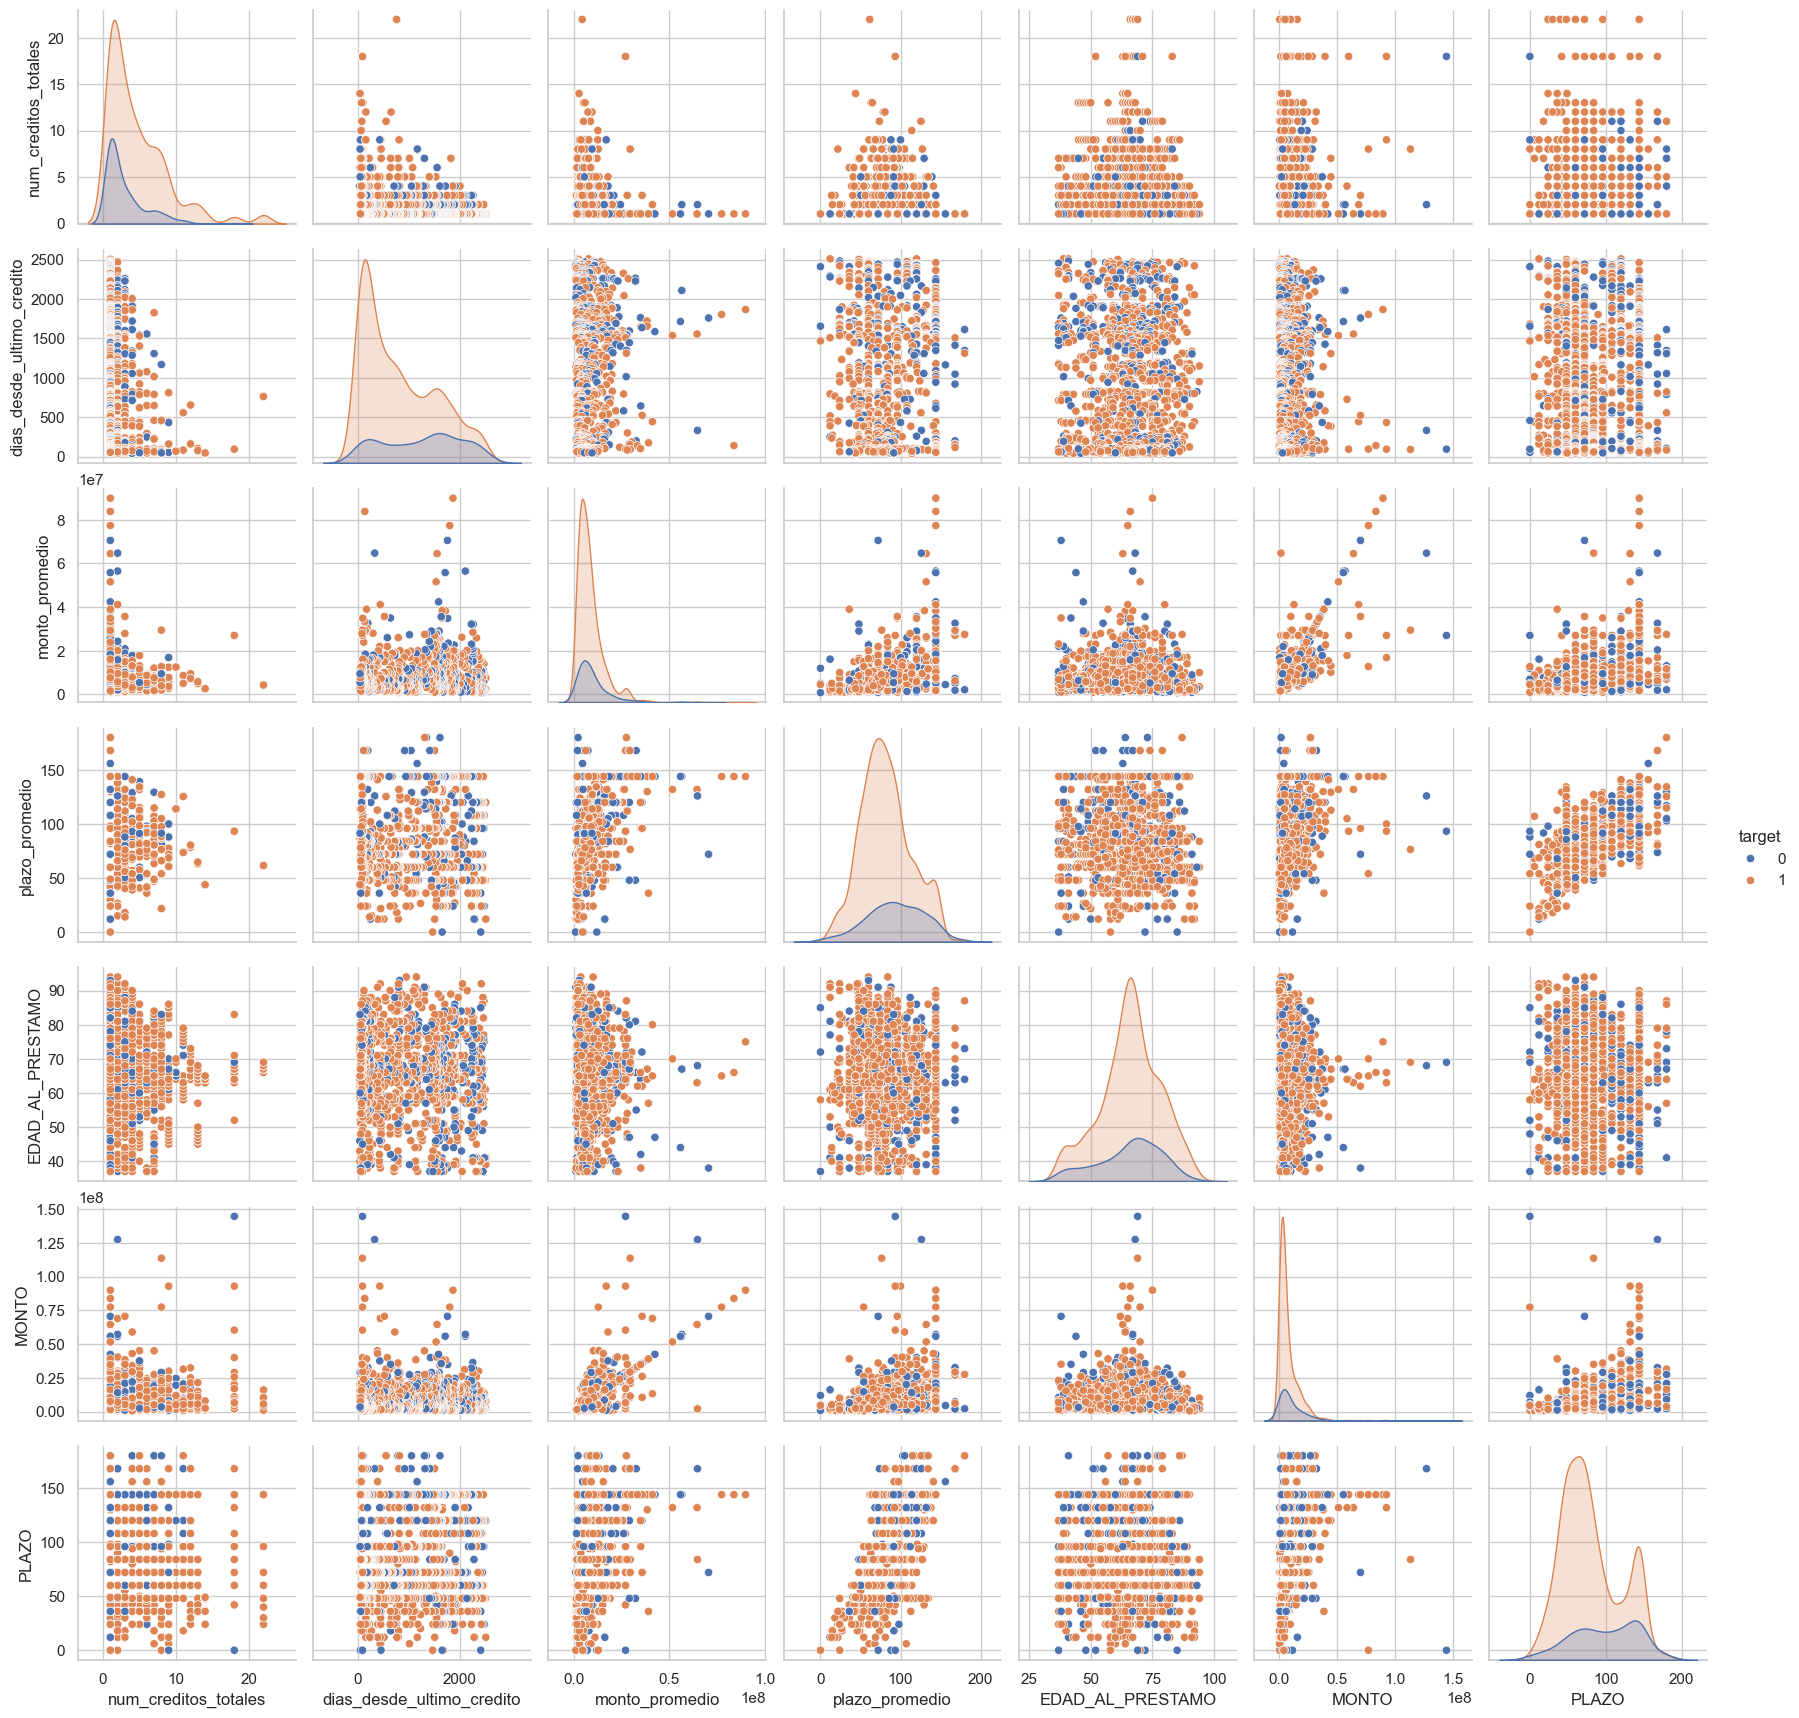

In [258]:
# PAIRPLOT
cols_pairplot = [
    'num_creditos_totales',
    'dias_desde_ultimo_credito',
    'monto_promedio',
    'plazo_promedio',
    'EDAD_AL_PRESTAMO',
    'MONTO',
    'PLAZO',
    'target'
]

df_pair = pd.concat([X[cols_pairplot[:-1]], y], axis=1)

sns.pairplot(df_pair, hue='target', diag_kind='kde')
plt.show()

In [259]:
X.info()

<class 'pandas.DataFrame'>
Index: 1611 entries, 0 to 1649
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MONTO                            1611 non-null   float64
 1   PLAZO                            1611 non-null   float64
 2   EDAD_AL_PRESTAMO                 1611 non-null   float64
 3   flag_refinanciado                1611 non-null   int64  
 4   num_creditos_totales             1611 non-null   float64
 5   dias_desde_ultimo_credito        1611 non-null   float64
 6   monto_promedio                   1611 non-null   float64
 7   plazo_promedio                   1611 non-null   float64
 8   TIPO DE CREDITO_DESCONOCIDO      1611 non-null   bool   
 9   TIPO DE CREDITO_LIBRE INVERSIÓN  1611 non-null   bool   
 10  TIPO DE CREDITO_OTROS            1611 non-null   bool   
 11  TIPO DE CREDITO_REFINANCIACIÓN   1611 non-null   bool   
 12  PAGADURIA_COLFONDOS              161

In [260]:
X = X.drop(columns=['monto_promedio', 'plazo_promedio'])

La selección de variables de entrada se realizó con base en la importancia de características obtenida mediante un modelo Random Forest, el cual permitió identificar el aporte relativo de cada variable al desempeño predictivo. Los resultados evidenciaron que dias_desde_ultimo_credito, MONTO, EDAD_AL_PRESTAMO, PLAZO y num_creditos_totales concentran la mayor capacidad explicativa del modelo, superando significativamente al resto de variables. Estas variables, además, son coherentes con la lógica del negocio, ya que capturan dimensiones clave como la recencia del comportamiento crediticio, el tamaño y duración de la solicitud, la experiencia financiera del cliente y su perfil demográfico. En particular, la relevancia de EDAD_AL_PRESTAMO confirma la existencia de relaciones no lineales que no habían sido evidentes en análisis de correlación, justificando su inclusión.

Por otro lado, las variables categóricas derivadas de TIPO DE CREDITO y PAGADURIA, así como la variable flag_refinanciado, fueron descartadas debido a su baja importancia relativa, lo que indica una contribución marginal al modelo. Mantener estas variables incrementaría la complejidad sin generar mejoras sustanciales en el desempeño, además de introducir posible redundancia o ruido. En este sentido, se optó por un conjunto reducido de variables que garantiza un modelo más eficiente, sin sacrificar capacidad predictiva, lo cual resulta adecuado para el objetivo del modelo de estimar probabilidades de aprobación dentro del sistema propuesto.

In [261]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

dias_desde_ultimo_credito          0.228365
MONTO                              0.218255
EDAD_AL_PRESTAMO                   0.177884
PLAZO                              0.147935
num_creditos_totales               0.091819
TIPO DE CREDITO_LIBRE INVERSIÓN    0.028660
PAGADURIA_COLPENSIONES             0.019706
PAGADURIA_OTROS                    0.017432
PAGADURIA_FIDUPREVISORA            0.010257
PAGADURIA_SEGUROS ALFA             0.008805
TIPO DE CREDITO_REFINANCIACIÓN     0.008134
flag_refinanciado                  0.008129
PAGADURIA_FOPEP                    0.008119
PAGADURIA_FERROCARRILES            0.006952
PAGADURIA_COLFONDOS                0.006304
PAGADURIA_PORVENIR                 0.004605
PAGADURIA_PROTECCION               0.003410
PAGADURIA_SEGUROS BOLIVAR          0.003245
TIPO DE CREDITO_DESCONOCIDO        0.001409
TIPO DE CREDITO_OTROS              0.000573
dtype: float64


# Modelos

In [262]:
#  FEATURES Y TARGET
features_finales = [
    'dias_desde_ultimo_credito',
    'MONTO',
    'PLAZO',
    'num_creditos_totales',
    'EDAD_AL_PRESTAMO'
]

UMBRAL = 0.6

df_model = pd.concat([X, y], axis=1).dropna()
X_final  = df_model[features_finales]
y_final  = df_model['target']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.3,
    random_state=42,
    stratify=y_final
)

# FUNCIÓN HELPER
def evaluar_modelo(nombre, y_test, y_pred, y_proba, clases):
    print("=" * 55)
    print(f"CLASSIFICATION REPORT — {nombre} (umbral {UMBRAL})")
    print("=" * 55)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clases, yticklabels=clases)
    plt.title(f'Matriz de confusión — {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()

## Random forest

Los resultados evidenciaron que el modelo Random Forest presenta el mejor equilibrio entre la correcta identificación de solicitudes aprobadas (clase mayoritaria) y la detección de solicitudes no aprobadas (clase minoritaria).

Adicionalmente, Random Forest demostró ser un modelo robusto frente al desbalance de clases, especialmente al incorporar estrategias como el ajuste de pesos mediante el parámetro class_weight, esto significa que:

Los errores en la clase minoritaria (por ejemplo, “no desembolsado”) se penalizan más.
El modelo presta más atención a aprender patrones de esa clase.
Se mejora la capacidad de detectar casos menos frecuentes sin modificar los datos originales.

Otro aspecto relevante es la capacidad del modelo para generar probabilidades de clasificación a través de la función predict_proba. Esta característica es fundamental, dado que el propósito del modelo no se limita a una clasificación binaria, sino que requiere estimar una probabilidad de aprobación que posteriormente será utilizada como insumo en un sistema híbrido de recomendación. En este sentido, Random Forest ofrece una salida probabilística estable y coherente con el comportamiento de los datos.

Finalmente, el modelo permite analizar la importancia de las variables, lo cual facilita la interpretación de los factores que influyen en la aprobación de créditos. Esto aporta valor adicional al análisis, al permitir validar que las variables más influyentes corresponden a aspectos relevantes desde el punto de vista del negocio, como el historial crediticio, el monto solicitado y la recencia de la actividad del cliente.

En consecuencia, se selecciona Random Forest como el modelo más adecuado para el desarrollo del Modelo 1, debido a su capacidad de generalización, su equilibrio en el desempeño entre clases, su robustez frente al desbalance de datos y su capacidad para generar probabilidades de aprobación útiles para la toma de decisiones en el sistema propuesto.

CLASSIFICATION REPORT — Random Forest (umbral 0.6)
              precision    recall  f1-score   support

           0       0.51      0.26      0.35        99
           1       0.83      0.94      0.88       385

    accuracy                           0.80       484
   macro avg       0.67      0.60      0.61       484
weighted avg       0.77      0.80      0.77       484



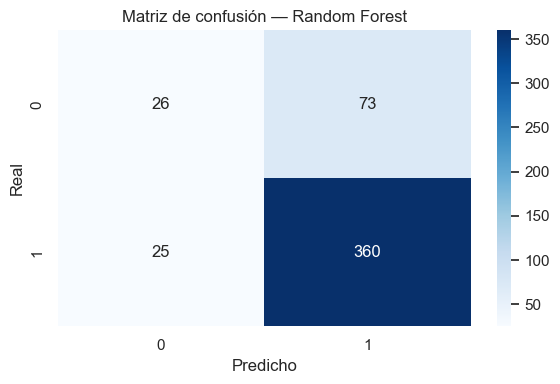

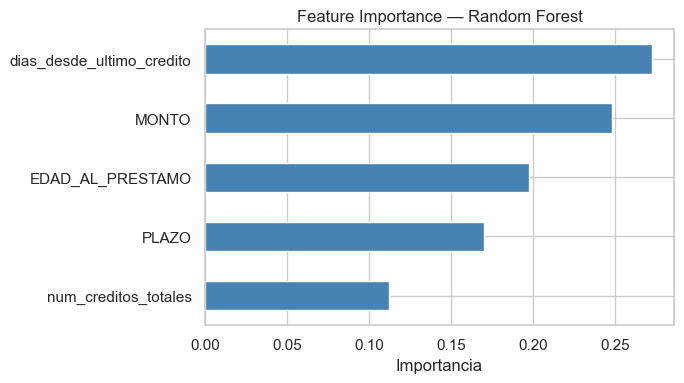

In [263]:

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf  = (y_proba_rf >= UMBRAL).astype(int)

evaluar_modelo('Random Forest', y_test, y_pred_rf, y_proba_rf, rf.classes_)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=features_finales).sort_values(ascending=True)
plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## XGBoost

El modelo XGBoost, basado en técnicas de boosting, construye árboles de decisión de forma secuencial, donde cada nuevo modelo corrige los errores del anterior mediante optimización de una función de pérdida. Este enfoque permite capturar relaciones complejas en los datos, aunque lo hace más sensible al ruido y a la configuración de hiperparámetros. En este caso, se utilizaron estrategias de regularización y ajuste de pesos para manejar el desbalance de clases y mejorar la capacidad de generalización.

En cuanto al desempeño, XGBoost alcanzó una exactitud del 69%, inferior a Random Forest, pero mostró una mejora significativa en la detección de la clase minoritaria (NO_DESEMBOLSADO), con un recall de 0.61. Esto indica que el modelo es más efectivo identificando solicitudes que no serán aprobadas. Sin embargo, esta mejora se logra a costa de una reducción en el recall de la clase mayoritaria (DESEMBOLSADO), que desciende a 0.71, aumentando así los falsos negativos.

Desde la perspectiva del objetivo del modelo, estimar la probabilidad de aprobación y servir como filtro de viabilidad, este comportamiento no resulta óptimo. Aunque XGBoost mejora la identificación de clientes no viables, reduce la capacidad de detectar correctamente aquellos con alta probabilidad de aprobación, que son precisamente los más relevantes para el sistema. Por esta razón, a pesar de sus ventajas, XGBoost no fue seleccionado como modelo principal frente a Random Forest.

In [264]:
!pip install xgboost

CLASSIFICATION REPORT — XGBoost (umbral 0.6)
              precision    recall  f1-score   support

           0       0.37      0.63      0.47        99
           1       0.88      0.73      0.80       385

    accuracy                           0.71       484
   macro avg       0.63      0.68      0.63       484
weighted avg       0.78      0.71      0.73       484



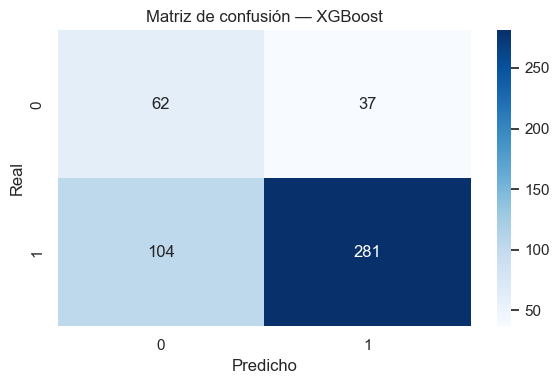

In [265]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb  = (y_proba_xgb >= UMBRAL).astype(int)

evaluar_modelo('XGBoost', y_test, y_pred_xgb, y_proba_xgb, [0, 1])

## SVM

El modelo SVM con kernel RBF es una técnica potente para modelar relaciones no lineales mediante la transformación de los datos a espacios de mayor dimensión. En este caso, se utilizó junto con un proceso de estandarización y ajuste de pesos para manejar el desbalance de clases. Su objetivo es maximizar el margen de separación entre clases, penalizando errores de clasificación mediante un esquema de optimización bien definido.

A pesar de alcanzar una exactitud cercana al 79%, el modelo mostró un comportamiento altamente desequilibrado. Mientras logra identificar casi todos los créditos desembolsados (recall de 0.99), falla significativamente en la detección de los no desembolsados (recall de 0.02). Esto indica que el modelo tiende a clasificar la mayoría de los casos como aprobados, sin discriminar adecuadamente entre ambas clases, lo cual se evidencia claramente en la matriz de confusión.

Desde la perspectiva del objetivo del modelo, estimar la probabilidad de aprobación de manera confiable, este comportamiento resulta inadecuado. Aunque SVM presenta buen desempeño global, su incapacidad para identificar correctamente la clase negativa limita su utilidad como filtro de viabilidad. Por esta razón, no fue seleccionado como modelo principal frente a Random Forest, que ofrece un mejor balance entre detección de clases y utilidad práctica en el sistema propuesto.

CLASSIFICATION REPORT — SVM (RBF) (umbral 0.6)
              precision    recall  f1-score   support

           0       0.40      0.02      0.04        99
           1       0.80      0.99      0.88       385

    accuracy                           0.79       484
   macro avg       0.60      0.51      0.46       484
weighted avg       0.72      0.79      0.71       484



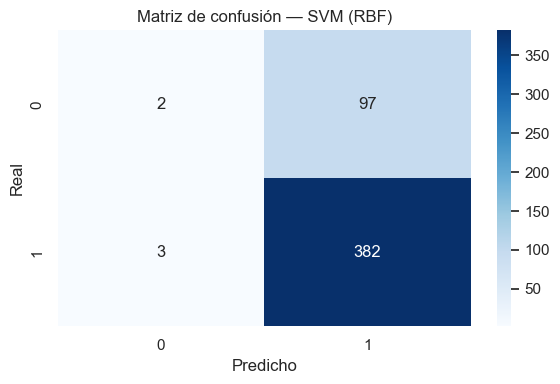

In [266]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        C=1.0,
        gamma='scale',
        random_state=42
    ))
])
svm.fit(X_train, y_train)

y_proba_svm = svm.predict_proba(X_test)[:, 1]
y_pred_svm  = (y_proba_svm >= UMBRAL).astype(int)

evaluar_modelo('SVM (RBF)', y_test, y_pred_svm, y_proba_svm, [0, 1])

## Comparación de modelos

In [267]:
resultados = pd.DataFrame({
    'Modelo':   ['Random Forest', 'XGBoost', 'SVM'],
    'F1 clase 0': [
        f1_score(y_test, y_pred_rf,  pos_label=0),
        f1_score(y_test, y_pred_xgb, pos_label=0),
        f1_score(y_test, y_pred_svm, pos_label=0)
    ],
    'F1 clase 1': [
        f1_score(y_test, y_pred_rf,  pos_label=1),
        f1_score(y_test, y_pred_xgb, pos_label=1),
        f1_score(y_test, y_pred_svm, pos_label=1)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_svm)
    ]
}).round(3)

print("\n" + "=" * 55)
print("COMPARACIÓN FINAL DE MODELOS")
print("=" * 55)
print(resultados.to_string(index=False))



COMPARACIÓN FINAL DE MODELOS
       Modelo  F1 clase 0  F1 clase 1  ROC AUC
Random Forest       0.347       0.880    0.716
      XGBoost       0.468       0.799    0.717
          SVM       0.038       0.884    0.700


## Guardar modelo

In [268]:
import joblib

# Guardar modelo
joblib.dump(rf, '../modelos/modelo1_random_forest.pkl')

print("Modelo guardado como 'modelo1_random_forest.pkl'")

Modelo guardado como 'modelo1_random_forest.pkl'
